In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(x_train.shape)
print(x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


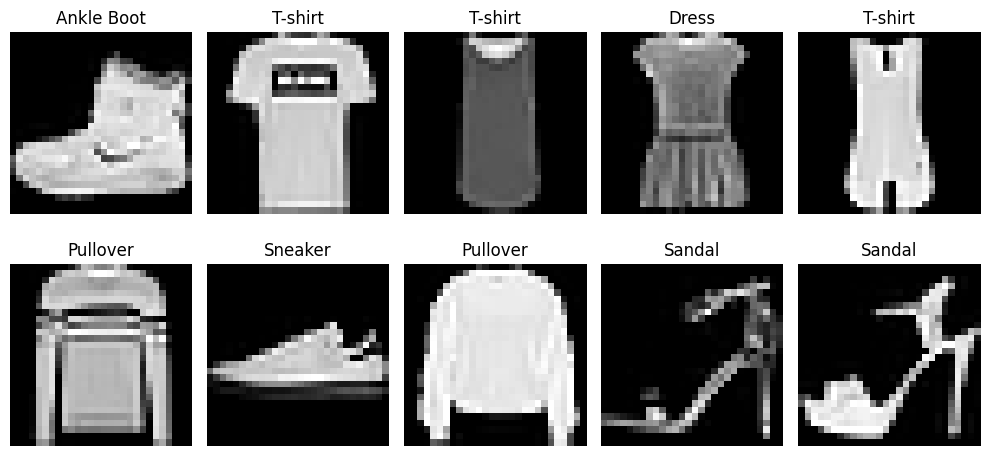

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1)
])

In [6]:
model = models.Sequential()

model.add(data_augmentation)

model.add(layers.Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(28,28,1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64,(3,3),padding="same",activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128,(3,3),padding="same",activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())

model.add(layers.Dense(256,activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(128,activation="relu"))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(10,activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [10]:
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 112s 149ms/step - accuracy: 0.8144 - loss: 0.5136 - val_accuracy: 0.8226 - val_loss: 0.4687 - learning_rate: 0.0010
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 110s 146ms/step - accuracy: 0.8250 - loss: 0.4833 - val_accuracy: 0.8372 - val_loss: 0.4316 - learning_rate: 0.0010
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 152ms/step - accuracy: 0.8319 - loss: 0.4584 - val_accuracy: 0.8086 - val_loss: 0.5238 - learning_rate: 0.0010
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 109s 145ms/step - accuracy: 0.8385 - loss: 0.4407 - val_accuracy: 0.8304 - val_loss: 0.4541 - learning_rate: 0.0010
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 146s 151ms/step - accuracy: 0.8528 - loss: 0.4044 - val_accuracy: 0.8426 - val_loss: 0.4256 - learning_rate: 5.0000e-04
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 108s 145ms/step - accuracy: 0.8576 - loss: 0.3922 - val_accuracy: 0.8239 - val_loss: 0.4928 - learning_rate: 5.0000e-04
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 152ms/step 

In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8778 - loss: 0.3313
Test Loss: 0.33128711581230164
Test Accuracy: 0.8777999877929688


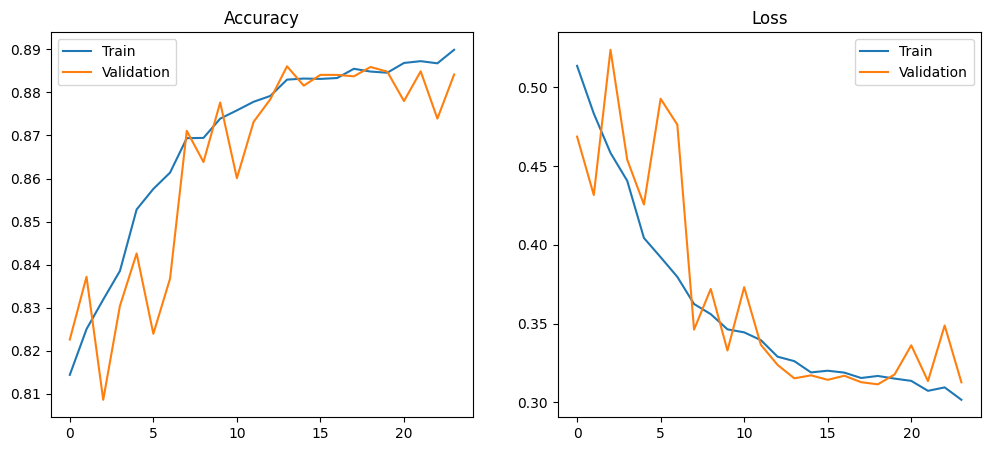

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Validation"])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Validation"])
plt.title("Loss")

plt.show()

In [13]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


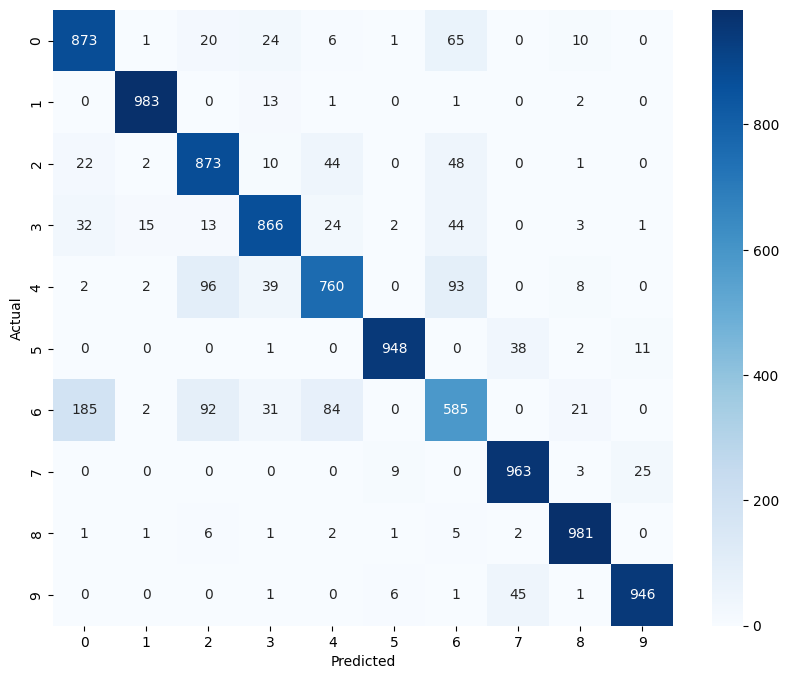

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.78      0.87      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.79      0.87      0.83      1000
       Dress       0.88      0.87      0.87      1000
        Coat       0.83      0.76      0.79      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.69      0.58      0.64      1000
     Sneaker       0.92      0.96      0.94      1000
         Bag       0.95      0.98      0.97      1000
  Ankle Boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



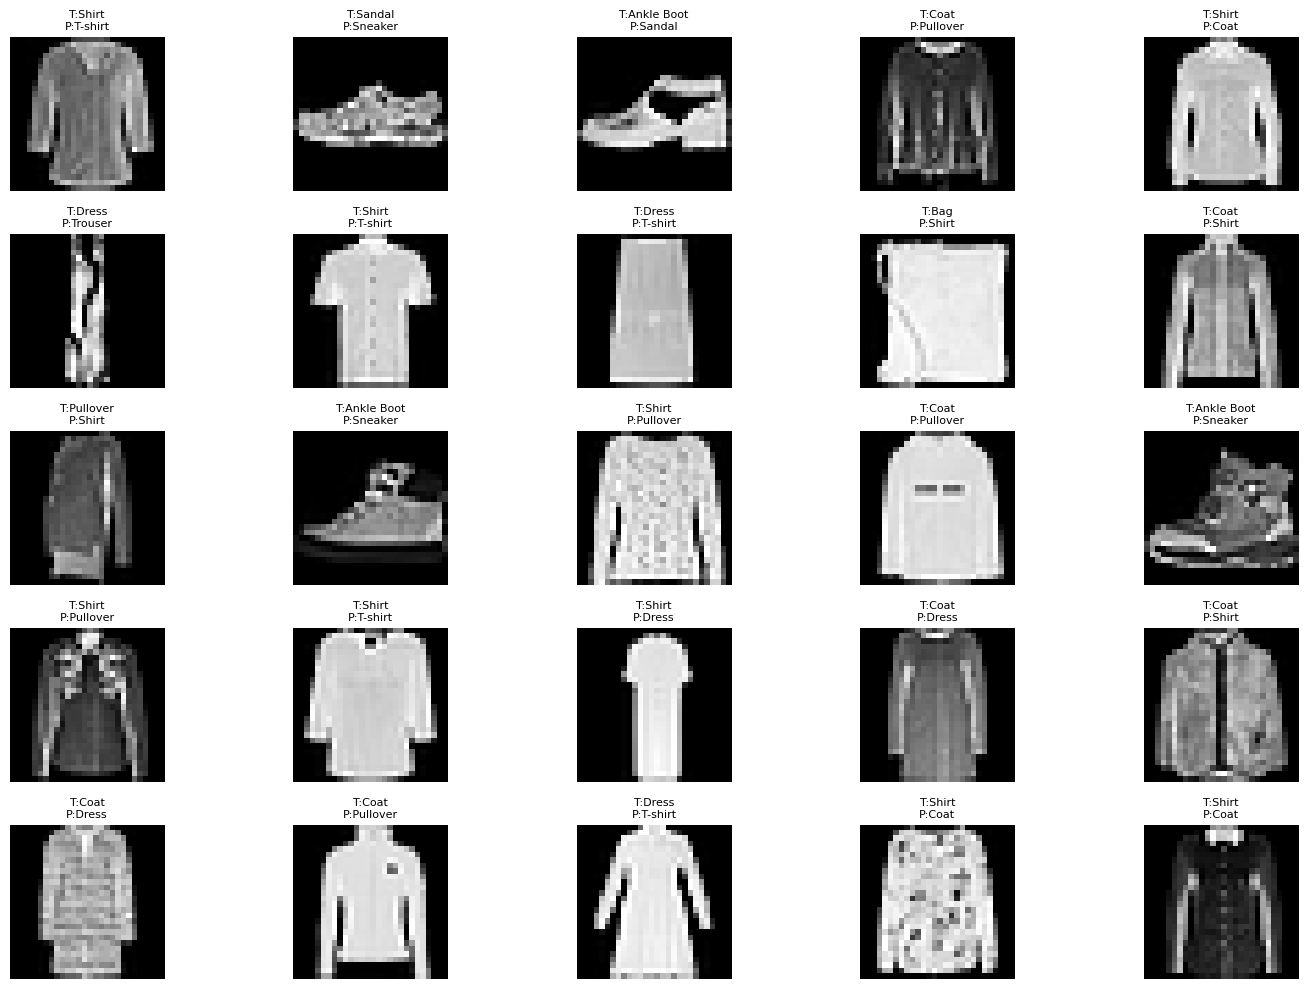

In [16]:
misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:25]):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(
        f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
model.save("fashion_mnist_cnn.h5")

print("Model Saved")

Model Saved


In [18]:
loaded_model = tf.keras.models.load_model("fashion_mnist_cnn.h5")

print("Model Reloaded")

Model Reloaded


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


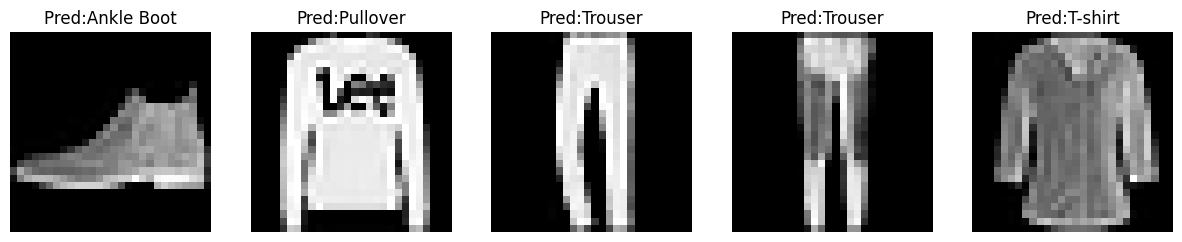

In [19]:
sample_images = x_test[:5]

predictions = loaded_model.predict(sample_images)

predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(
        f"Pred:{class_names[predicted_classes[i]]}"
    )
    plt.axis("off")

plt.show()

In [20]:
readme = f"""
END TO END IMAGE CLASSIFICATION PROJECT

Dataset
Fashion-MNIST Dataset

Number of Classes
10

Image Size
28 x 28

Architecture

Conv2D 32
BatchNormalization
MaxPooling

Conv2D 64
BatchNormalization
MaxPooling

Conv2D 128
BatchNormalization
MaxPooling

Dense 256
Dropout 0.5

Dense 128
Dropout 0.3

Output Layer Softmax

Regularization

Batch Normalization
Dropout
Early Stopping
ReduceLROnPlateau

Augmentation

Random Flip
Random Rotation
Random Zoom
Random Translation

Optimizer

Adam

Loss Function

Sparse Categorical Crossentropy

Final Test Accuracy

{test_accuracy:.4f}
"""

with open("README.txt","w") as f:
    f.write(readme)

print("README Created")

README Created


In [21]:
from google.colab import files

files.download("README.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>